In [ ]:
### Import the necessary Libraries

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###Load The Needed Dataset

In [ ]:
uploaded=files.upload()

Saving OnlineRetail.csv to OnlineRetail (1).csv


Read The Files As A Dataframe

In [ ]:
df=pd.read_csv ('OnlineRetail.csv',encoding='latin1')
df.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


Number of Rows and Columns

In [ ]:
print("Shape:",df.shape)

rows=df.shape[0]
columns=df.shape[1]

print("Number of rows:",rows)
print("Number of columns:",columns)

Shape: (541909, 8)
Number of rows: 541909
Number of columns: 8


Data Types of All Columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.columns=df.columns.str.lower()


Numerical Features And Categorical Features

In [ ]:
numerical_features=df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features=df.select_dtypes(include=['object','category']).columns.tolist()

print("Numerical Features:",numerical_features)
print("Categorical Features:",categorical_features)

Numerical Features: ['quantity', 'unitprice', 'customerid']
Categorical Features: ['invoiceno', 'stockcode', 'description', 'invoicedate', 'country']


Possible Unique Identifiers (Primary Keys)

In [ ]:
for col in df.columns:
    if df[col].is_unique and df[col].notna().all():
        print(f"{col} could be a primary key")

Handling Missing Values

In [ ]:
missing_values=df.isnull().sum()
print('Number of missing values for each variable:')
missing_values


Number of missing values for each variable:


,0
invoiceno,0
stockcode,0
description,1454
quantity,0
invoicedate,0
unitprice,0
customerid,135080
country,0


In [ ]:
df['description']=df['description'].fillna('Unknown Product')

Duplicate Records

In [ ]:
###Sum of Duplicates
df.duplicated().sum()

###Drop Duplicates
df=df.drop_duplicates()

Standardization

In [ ]:
# Standardize Column Names
df.columns = df.columns.str.lower().str.strip()

print("\nStandardized Column Names")
print(df.columns)

# Standardize Text Columns
df['description'] = df['description'].str.title()
df['country'] = df['country'].str.title()

# Standardize Date Format
df['invoicedate'] = pd.to_datetime(df['invoicedate'])




Standardized Column Names
Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')


Text Formatting

In [ ]:
df['description']=df['description'].str.title()
df['country']=df['country'].str.title()

Column Names

In [ ]:
df.columns=df.columns.str.lower()


Create Sales Column


In [ ]:
df['sales'] = df['quantity'] * df['unitprice']


Data Validation

In [ ]:
# Negative Quantities (Returns)
negative_qty = df[df['quantity'] < 0]

print(f"Negative Quantity Records: {len(negative_qty)}")

# Negative Prices
negative_price = df[df['unitprice'] < 0]

print(f"Negative Price Records: {len(negative_price)}")

# Remove Invalid Prices
df = df[df['unitprice'] > 0]


Negative Quantity Records: 10587
Negative Price Records: 2


# Outlier Detection (IQR Method)

In [ ]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['sales'] < lower_bound) |
    (df['sales'] > upper_bound)
]

print(f"Sales Outliers Found: {len(outliers)}")

Sales Outliers Found: 45114


In [ ]:
print(df.head())

  invoiceno stockcode                          description  quantity  \
0    536365    85123A   White Hanging Heart T-Light Holder         6   
1    536365     71053                  White Metal Lantern         6   
2    536365    84406B       Cream Cupid Hearts Coat Hanger         8   
3    536365    84029G  Knitted Union Flag Hot Water Bottle         6   
4    536365    84029E       Red Woolly Hottie White Heart.         6   

          invoicedate  unitprice  customerid         country  sales  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  


In [ ]:
## Cleaning Summary
cleaning_summary = pd.DataFrame({
    'Issue Found': [
        'Missing Description',
        'Missing CustomerID',
        'Duplicates',
        'Column Names',
        'Date Format',
        'Invalid Prices'
    ],
    'Action Taken': [
        'Filled with Unknown Product',
        'Removed Rows',
        'Removed Duplicates',
        'Standardized',
        'Converted to Datetime',
        'Removed Records'
    ]
})

print("\nCleaning Summary")
print(cleaning_summary)


Cleaning Summary
           Issue Found                 Action Taken
0  Missing Description  Filled with Unknown Product
1   Missing CustomerID                 Removed Rows
2           Duplicates           Removed Duplicates
3         Column Names                 Standardized
4          Date Format        Converted to Datetime
5       Invalid Prices              Removed Records


In [ ]:
### Summary Statistics
print("\nSummary Statistics")
print(df.describe())

# Mean
print("\nMean")
print(df[numerical_features].mean())

# Median
print("\nMedian")
print(df[numerical_features].median())

# Min
print("\nMinimum")
print(df[numerical_features].min())

# Max
print("\nMaximum")
print(df[numerical_features].max())

# Standard Deviation
print("\nStandard Deviation")
print(df[numerical_features].std())


Summary Statistics
            quantity                    invoicedate      unitprice  \
count  534129.000000                         534129  534129.000000   
mean        9.916818  2011-07-04 12:02:01.631403776       4.695864   
min    -80995.000000            2010-12-01 08:26:00       0.001000   
25%         1.000000            2011-03-28 11:36:00       1.250000   
50%         3.000000            2011-07-19 15:55:00       2.100000   
75%        10.000000            2011-10-18 17:10:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       216.452113                            NaN      95.079189   

          customerid          sales  
count  401564.000000  534129.000000  
mean    15281.266797      18.250518  
min     12346.000000 -168469.600000  
25%     13939.000000       3.750000  
50%     15145.000000       9.900000  
75%     16788.000000      17.570000  
max     18287.000000  168469.600000  
std      1713.978947     380.945385  

Mean
q

In [ ]:
print(df.columns.tolist())

['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'sales']


EDA 1: Top Selling Products


Top Selling Products
description
World War 2 Gliders Asstd Designs     53751
Jumbo Bag Red Retrospot               47256
Popcorn Holder                        36322
Assorted Colour Bird Ornament         36282
Pack Of 72 Retrospot Cake Cases       36016
White Hanging Heart T-Light Holder    35294
Rabbit Night Light                    30631
Mini Paint Set Vintage                26437
Pack Of 12 London Tissues             26095
Pack Of 60 Pink Paisley Cake Cases    24719
Name: quantity, dtype: int64


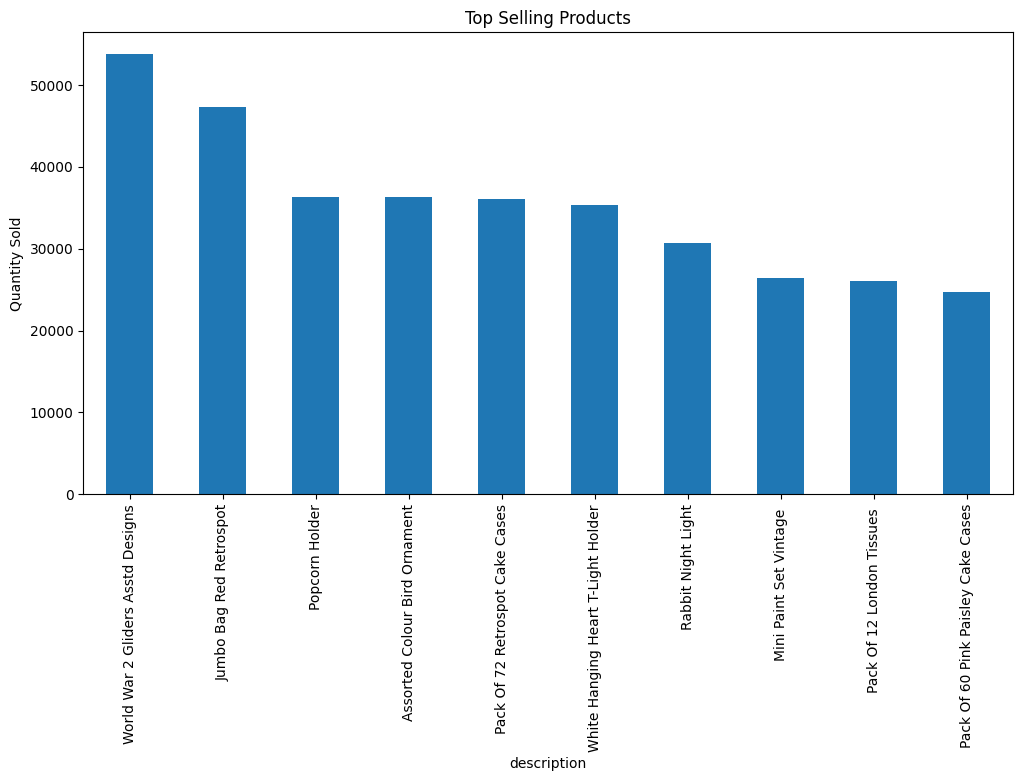

In [ ]:
top_products = (
    df.groupby('description')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop Selling Products")
print(top_products)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title('Top Selling Products')
plt.ylabel('Quantity Sold')
plt.show()


EDA 2: Highest Revenue Countries


Highest Revenue Countries
country
United Kingdom    8189252.304
Netherlands        284661.540
Eire               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: sales, dtype: float64


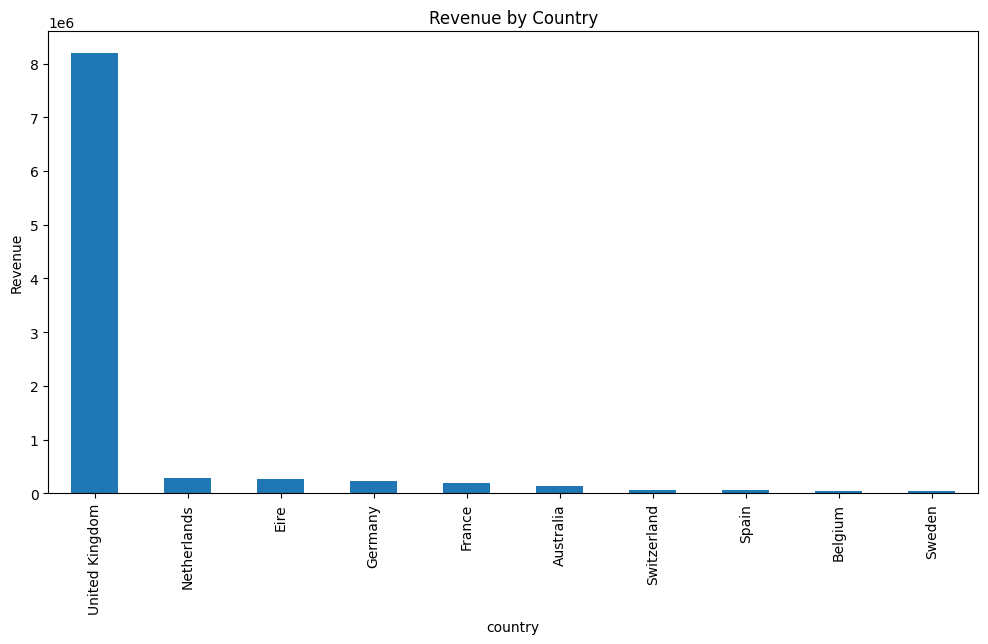

In [ ]:
country_sales = (
    df.groupby('country')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nHighest Revenue Countries")
print(country_sales)

plt.figure(figsize=(12,6))
country_sales.plot(kind='bar')
plt.title('Revenue by Country')
plt.ylabel('Revenue')
plt.show()

# EDA 3: Monthly Sales Trend


Monthly Sales Trend
month
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     703510.580
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: sales, dtype: float64


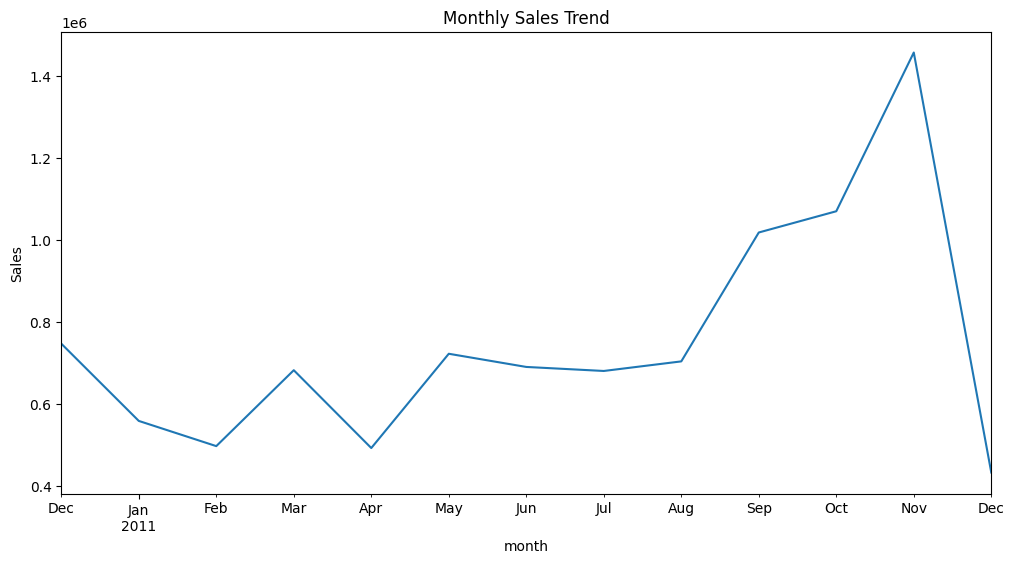

In [ ]:
df['month'] = df['invoicedate'].dt.to_period('M')

monthly_sales = (
    df.groupby('month')['sales']
    .sum()
)

print("\nMonthly Sales Trend")
print(monthly_sales)

monthly_sales.plot(figsize=(12,6))
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()


# EDA 4: Most Purchased Products


Most Frequently Purchased Products
description
White Hanging Heart T-Light Holder    2353
Regency Cakestand 3 Tier              2187
Jumbo Bag Red Retrospot               2153
Party Bunting                         1719
Lunch Bag Red Retrospot               1625
Assorted Colour Bird Ornament         1488
Set Of 3 Cake Tins Pantry Design      1465
Pack Of 72 Retrospot Cake Cases       1367
Lunch Bag  Black Skull.               1323
Natural Slate Heart Chalkboard        1272
Name: quantity, dtype: int64


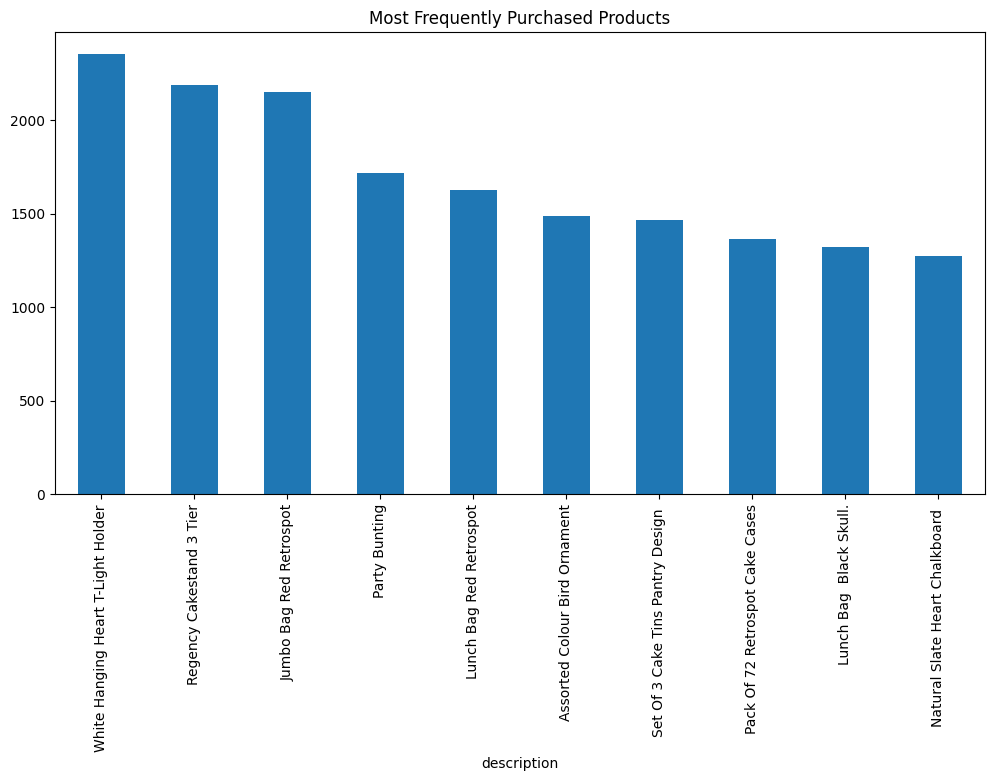

In [ ]:
most_purchased = (
    df.groupby('description')['quantity']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print("\nMost Frequently Purchased Products")
print(most_purchased)

plt.figure(figsize=(12,6))
most_purchased.plot(kind='bar')
plt.title('Most Frequently Purchased Products')
plt.show()

# EDA 5: Customer Purchasing Behaviour


Customer Purchasing Behavior
              sales  number_of_orders
customerid                           
12346.0        0.00                 2
12347.0     4310.00               182
12348.0     1797.24                31
12349.0     1757.55                73
12350.0      334.40                17

Top Customers by Revenue
                sales  number_of_orders
customerid                             
14646.0     279489.02              2081
18102.0     256438.49               433
17450.0     187322.17               350
14911.0     132458.73              5896
12415.0     123725.45               776
14156.0     113214.59              1415
17511.0      88125.38              1076
16684.0      65892.08               281
13694.0      62690.54               584
15311.0      59284.19              2478


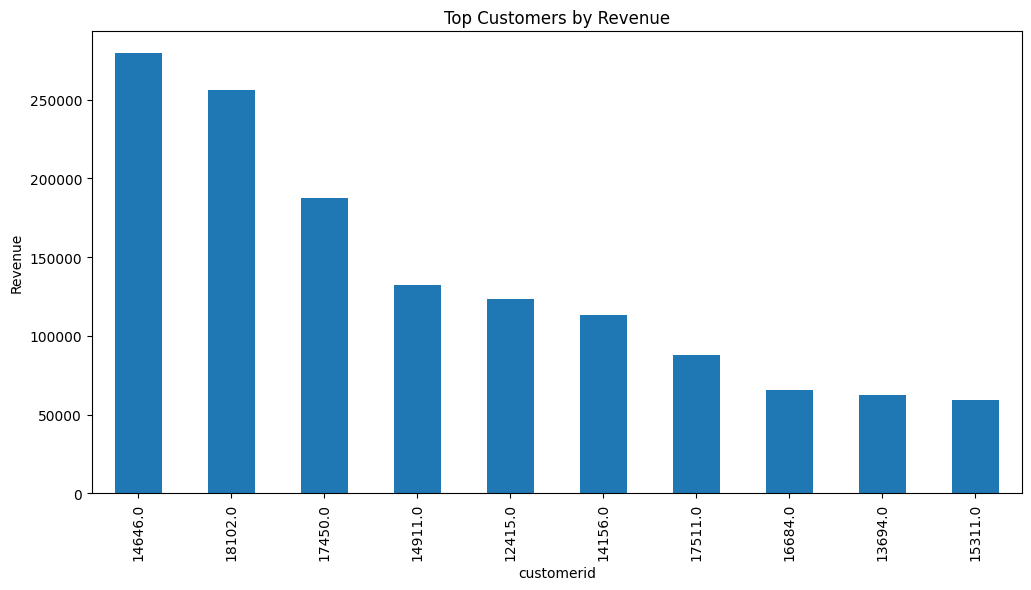

In [ ]:
customer_behavior = (
    df.groupby('customerid')
    .agg({
        'sales':'sum',
        'invoiceno':'count'
    })
    .rename(columns={'invoiceno':'number_of_orders'})
)

print("\nCustomer Purchasing Behavior")
print(customer_behavior.head())

top_customers = customer_behavior.sort_values(
    by='sales',
    ascending=False
).head(10)

print("\nTop Customers by Revenue")
print(top_customers)

plt.figure(figsize=(12,6))
top_customers['sales'].plot(kind='bar')
plt.title('Top Customers by Revenue')
plt.ylabel('Revenue')
plt.show()

 # Bonus Analysis



Average Order Value: 409.65


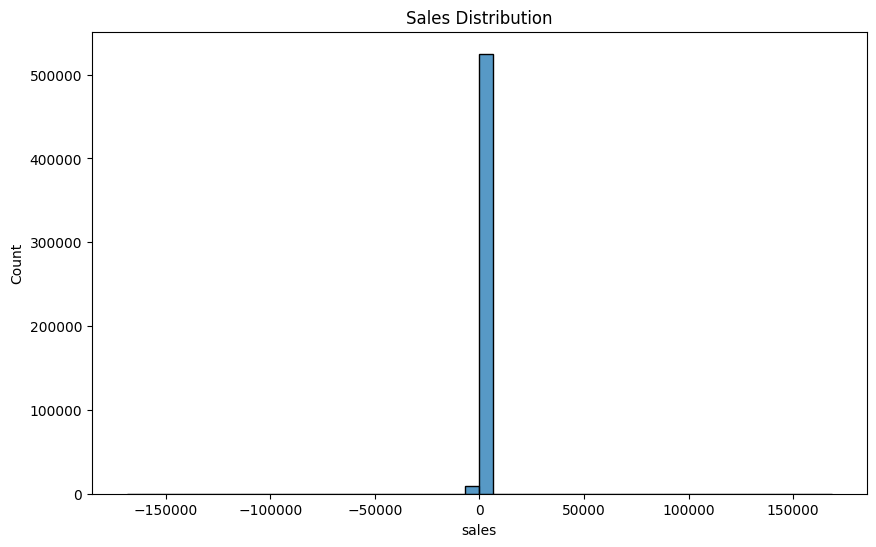


Analysis Completed Successfully!


In [ ]:
# Average Order Value

order_value = (
    df.groupby('invoiceno')['sales']
    .sum()
)

avg_order_value = order_value.mean()

print(f"\nAverage Order Value: {avg_order_value:.2f}")

# Revenue Distribution

plt.figure(figsize=(10,6))
sns.histplot(df['sales'], bins=50)
plt.title('Sales Distribution')
plt.show()

print("\nAnalysis Completed Successfully!")

In [ ]:
df.to_csv('OnlineRetail.csv', index=False)

In [ ]:
from google.colab import  files
files.download('OnlineRetail.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>